## Importamos las librerías

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import KNNImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder

## 1- Data cleaning

In [41]:
bd = pd.read_csv('../Datos/metadata.csv')
display(bd.head())

bd["img_id"] = bd.groupby("lesion_id")["img_id"].transform(lambda x: ", ".join(x))

df_img = bd[["lesion_id","img_id"]].copy()
df = bd.drop(columns=["img_id"]).copy()

,patient_id,lesion_id,smoke,drink,background_father,background_mother,age,pesticide,gender,skin_cancer_history,...,diameter_2,itch,grew,hurt,changed,bleed,elevation,img_id,biopsed,diagnostic
0,PAT_715,4072,False,True,POMERANIA,POMERANIA,80,True,MALE,False,...,2.0,FALSE,FALSE,FALSE,FALSE,FALSE,TRUE,PAT_715_4072_827.png,False,ACK
1,PAT_217,963,False,True,POMERANIA,POMERANIA,76,False,MALE,False,...,5.0,TRUE,FALSE,FALSE,FALSE,TRUE,FALSE,PAT_217_963_806.png,False,ACK
2,PAT_86,1082,False,False,POMERANIA,POMERANIA,53,False,FEMALE,True,...,15.0,TRUE,TRUE,TRUE,FALSE,TRUE,TRUE,PAT_86_1082_41.png,True,ACK
3,PAT_880,1675,False,False,GERMANY,GERMANY,83,False,FEMALE,True,...,40.0,TRUE,FALSE,TRUE,FALSE,FALSE,FALSE,PAT_880_1675_704.png,True,ACK
4,PAT_86,1082,False,False,POMERANIA,POMERANIA,53,False,FEMALE,True,...,15.0,TRUE,TRUE,TRUE,FALSE,TRUE,TRUE,PAT_86_1082_220.png,True,ACK


In [42]:
# Contar filas que son exactamente iguales en todo el DataFrame
total_duplicados = df.duplicated().sum()
print(f"Total de filas que son copias exactas: {total_duplicados}")

# Eliminamos las filas que son 100% idénticas
df = df.drop_duplicates(keep='first')

# Verificamos cuántas filas nos quedan
print(f"Registros después de eliminar duplicados exactos: {len(df)}")

Total de filas que son copias exactas: 94
Registros después de eliminar duplicados exactos: 708


### Preprocessing de NaNs

Vemos que columnas tienen NaN

In [43]:
NaN = pd.DataFrame({"Count":df.isnull().sum(),"Porcentaje":round(df.isnull().sum()/len(df)*100,2)})
NaN = NaN.sort_values(by="Count", ascending=False)
NaN = NaN[NaN["Count"]>0]
display(NaN)

,Count,Porcentaje
background_mother,169,23.87
background_father,168,23.73
gender,163,23.02
drink,163,23.02
smoke,163,23.02
pesticide,163,23.02
has_piped_water,163,23.02
cancer_history,163,23.02
skin_cancer_history,163,23.02
fitspatrick,163,23.02


Para las columnas booleanas vamos a cambiar los NaN, por una variable llamada (Unknown)

In [44]:
cols_para_fix = ['smoke', 'drink','pesticide','gender','skin_cancer_history','cancer_history','has_piped_water','has_sewage_system']
df[cols_para_fix] = df[cols_para_fix].fillna('Unknown')

Vamos a ver como se distribuyen las columnas con valor discreto (background_father, background_mother y fitspatrick)

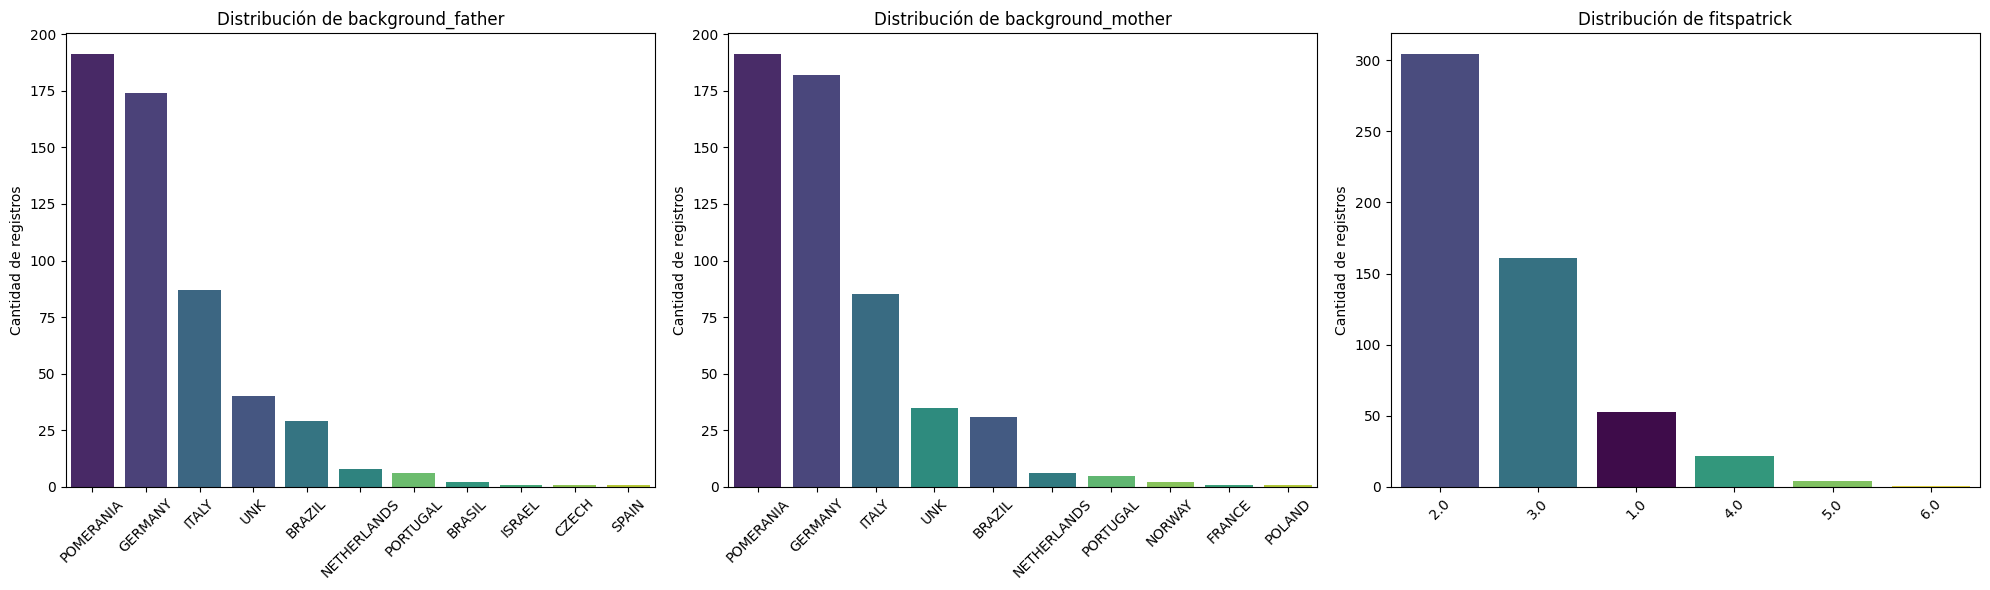

In [45]:
cols_discretas = ['background_father', 'background_mother', 'fitspatrick']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, col in enumerate(cols_discretas):
    # Ordenamos los datos para el eje X
    order = df[col].value_counts().index
    
    # Solución al Future濃厚Warning: asignamos x a hue y legend=False
    sns.countplot(
        data=df, 
        x=col, 
        ax=axes[i], 
        hue=col, 
        palette='viridis', 
        order=order, 
        legend=False
    )
    
    axes[i].set_title(f'Distribución de {col}')
    
    # Solución al UserWarning: Usar tick_params en lugar de set_xticklabels 
    # o simplemente rotar sin re-etiquetar
    axes[i].tick_params(axis='x', rotation=45)
    
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Cantidad de registros')

plt.tight_layout()
plt.show()

Vamos a rellenar los NaN en función de los porcentajes que se observan en los histogramas, esto quiere decir que por ejemplo, si en a columna fitspatrick hay un 55% de que el NaN se sustituya por "2.0" se utilizará ese porcentaje.

In [46]:
# Para que los resultados sean siempre los mismos al ejecutar
np.random.seed(42) 

for col in cols_discretas:
    # 1. Calculamos la distribución ignorando los NaNs
    # value_counts() por defecto no cuenta los nulos
    counts = df[col].value_counts(normalize=True)
    categorias = counts.index
    probabilidades = counts.values
    
    # 2. Identificamos qué filas tienen el valor nulo (NaN)
    mask_nulos = df[col].isnull()
    cantidad_a_rellenar = mask_nulos.sum()
    
    # 3. Si hay nulos, rellenamos con el "sorteo" basado en los porcentajes
    if cantidad_a_rellenar > 0:
        valores_imputados = np.random.choice(
            categorias, 
            size=cantidad_a_rellenar, 
            p=probabilidades
        )
        
        # 4. Sustituimos los NaN por los valores sorteados
        df.loc[mask_nulos, col] = valores_imputados

Ahora solo quedan dos columnas con NaNs, diameter_1 y diameter_2. Estas tienen valores continuas, así que vamos a observar sus distribuciones

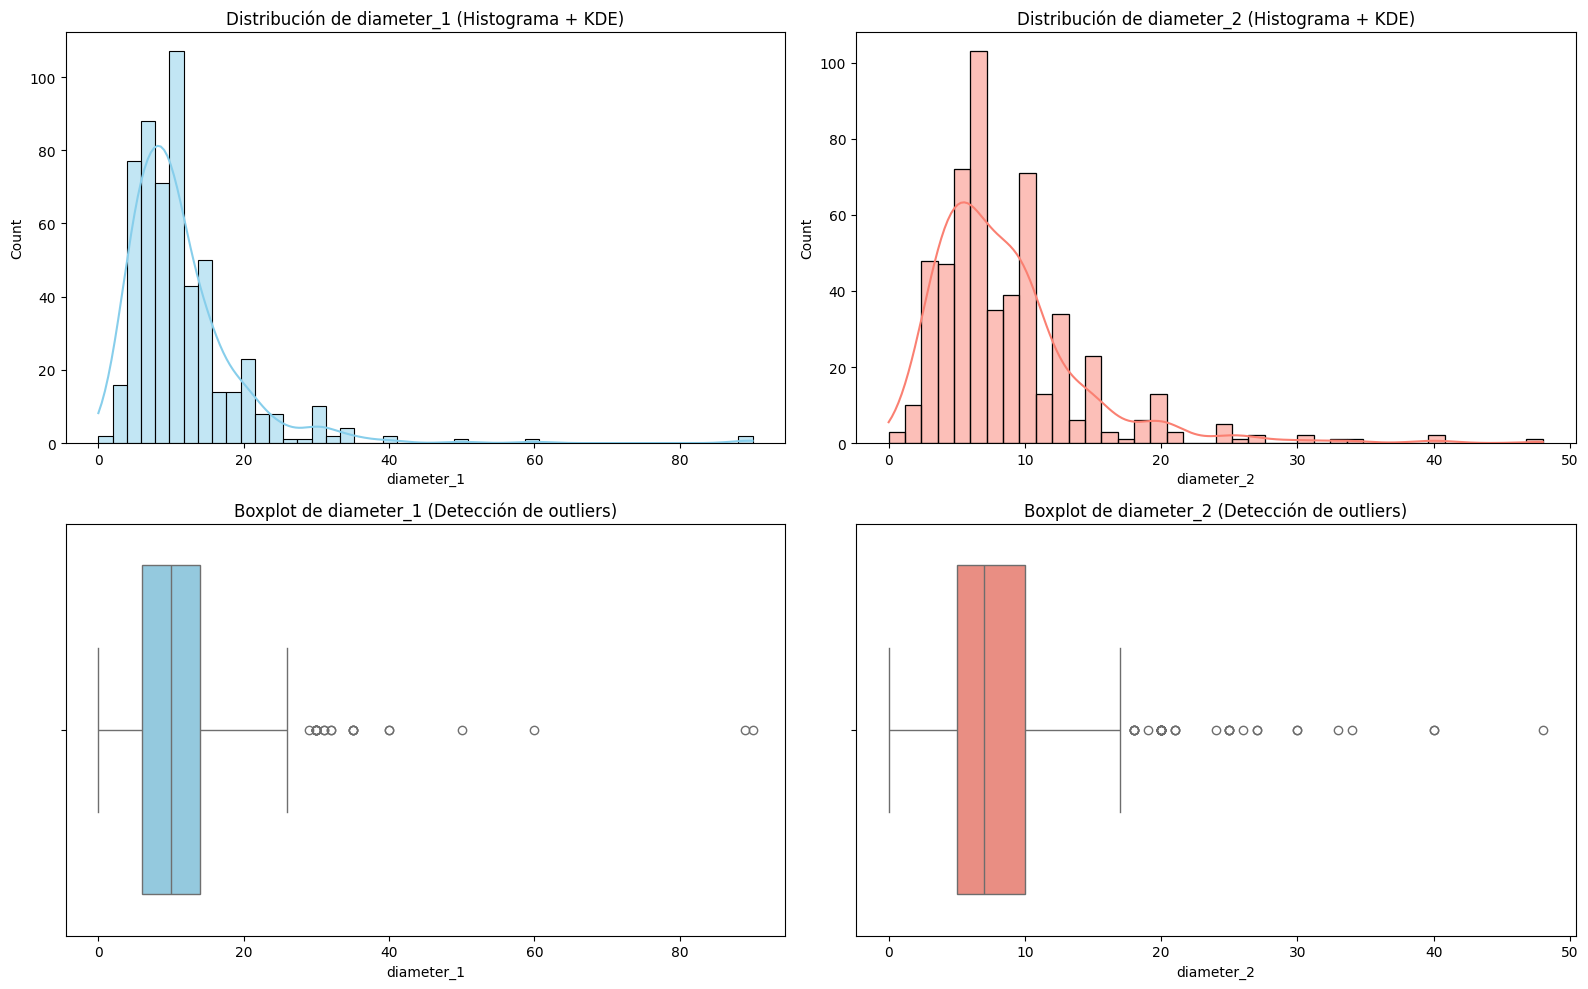

,diameter_1,diameter_2
count,545.000000,545.000000
mean,11.390826,8.574312
std,8.423723,5.642088
min,0.000000,0.000000
25%,6.000000,5.000000
50%,10.000000,7.000000
75%,14.000000,10.000000
max,90.000000,48.000000


In [47]:
# Configuramos el lienzo para 4 gráficos (2 por columna)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# --- Análisis de diameter_1 ---
sns.histplot(df['diameter_1'].dropna(), kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Distribución de diameter_1 (Histograma + KDE)')

sns.boxplot(x=df['diameter_1'], ax=axes[1, 0], color='skyblue')
axes[1, 0].set_title('Boxplot de diameter_1 (Detección de outliers)')

# --- Análisis de diameter_2 ---
sns.histplot(df['diameter_2'].dropna(), kde=True, ax=axes[0, 1], color='salmon')
axes[0, 1].set_title('Distribución de diameter_2 (Histograma + KDE)')

sns.boxplot(x=df['diameter_2'], ax=axes[1, 1], color='salmon')
axes[1, 1].set_title('Boxplot de diameter_2 (Detección de outliers)')

plt.tight_layout()
plt.show()

# Estadisticas
display(df[['diameter_1', 'diameter_2']].describe())

Para completar los NaNs, vamos a utilizar imputación KNN, la cual permite rellenar los huecos basándose en el perfil de pacientes con características similares en lugar de usar una media o mediana. Esto último se descarta debido a que estos métodos asignan un valor idéntico a todos los registros, ignorando las particularidades de cada caso y reduciendo artificialmente la variabilidad de los datos. Esto tiene sentido, ya que el tamaño de una lesión no es un evento aleatorio, sino que suele estar condicionado por otros factores, como los que tenemos como columnas. Al emplear este método, se logra preservar la distribución original de la muestra, manteniendo la proporción real entre lesiones pequeñas y grandes sin distorsionar los datos. Asimismo, este procedimiento permite gestionar adecuadamente los outliers, asegurando que estos registros médicos tan relevantes no se pierdan, pero evitando a la vez que su valor extremo afecte artificialmente al resto de las estimaciones, garantizando así un dataset final mucho más preciso y cercano a la realidad clínica.

In [48]:
df_knn = df.copy()

# 1) Detectar categóricas (incluye category y bool)
categorical_cols = df_knn.select_dtypes(include=["object", "bool", "category"]).columns

# 2) Quitar/gestionar datetimes (si existen)
datetime_cols = df_knn.select_dtypes(include=["datetime64[ns]", "timedelta64[ns]"]).columns
df_knn = df_knn.drop(columns=datetime_cols)

# 3) Mantener missing (NO usar astype(str))
for col in categorical_cols:
    df_knn[col] = df_knn[col].astype("string")

encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1,
    encoded_missing_value=np.nan
)

df_knn[categorical_cols] = encoder.fit_transform(df_knn[categorical_cols])

# 4) Imputación KNN
imputer = KNNImputer(n_neighbors=5)
df_imputed = pd.DataFrame(imputer.fit_transform(df_knn), columns=df_knn.columns, index=df_knn.index)

# 5) Volcar columnas de interés
df["diameter_1"] = df_imputed["diameter_1"]
df["diameter_2"] = df_imputed["diameter_2"]

## 2- Data Encoding

### Convertir a valor numérico las columnas con One_Hot Encoding

Para transformar los datos de texto a números, se ha utilizado One-Hot Encoding en lugar de asignar números seguidos (1, 2, 3...) porque la mayoría de las categorías no tienen un orden lógico. Si asignáramos números correlativos a variables como el sexo o el país de origen, el modelo podría pensar erróneamente que una opción es "más importante" o "vale más" que otra solo por tener un número más alto. Al crear columnas independientes de ceros y unos, nos aseguramos de que el modelo trate cada característica de forma justa y separada, evitando errores de interpretación y respetando la realidad de los datos médicos.

In [49]:
# 1. Identificamos las columnas categóricas
cols_categoricas = df.select_dtypes(include=['object', 'bool']).columns.tolist()

# Quitamos 'diagnostic' de la lista de transformación 
if 'diagnostic' in cols_categoricas:
    cols_categoricas.remove('diagnostic')
if 'patient_id' in cols_categoricas:
    cols_categoricas.remove('patient_id')

# Aplicamos One-Hot Encoding solo a las demás columnas
df_encoded = pd.get_dummies(
    df, 
    columns=cols_categoricas, 
    prefix_sep='_', 
    dtype=int
)

### Convertimos la columna que será el target (diagnostic) a número sin One-Hot Encoding

In [50]:
# 1. Creamos el codificador
le = LabelEncoder()

# 2. Aplicamos la transformación a la columna diagnostic
# Lo hacemos sobre el DataFrame 'df_encoded' que ya tiene el resto procesado
df_encoded['diagnostic'] = le.fit_transform(df_encoded['diagnostic'])

# 3. Creamos un diccionario para ver la correspondencia
mapeo_diagnostico = dict(zip(le.classes_, le.transform(le.classes_)))

print("--- Mapeo de Diagnósticos ---")
for nombre, numero in mapeo_diagnostico.items():
    print(f"Número {numero}: {nombre}")

--- Mapeo de Diagnósticos ---
Número 0: ACK
Número 1: BCC
Número 2: MEL
Número 3: NEV
Número 4: SCC
Número 5: SEK


## 3- Anexamos la columna `img_id` y agregamos una columna de diagnostico (Benigno y Maligno)

In [52]:
df_final = df_encoded.merge(df_img, on="lesion_id", how="left")

# Creamos un diccionario de mapeo
mapping = {
    0: 0,  # ACK -> Benigno 
    1: 1,  # BCC -> Maligno
    2: 1,  # MEL -> Maligno
    3: 0,  # NEV -> Benigno
    4: 1,  # SCC -> Maligno
    5: 0   # SEK -> Benigno
}

# Creamos la nueva columna
df_final['diagnostic_binario'] = df_final['diagnostic'].map(mapping)

# Verificamos el conteo de la nueva distribución
print(df_final['diagnostic_binario'].value_counts())

diagnostic_binario
0    503
1    374
Name: count, dtype: int64


## 3- Descargamos el .csv

In [53]:
#Lo descargamos en un csv
df_final.to_csv('../Datos/PreprocessedData.csv', index=False, sep=',')